[목록 수집] page=1/10 | url=https://kin.naver.com/qna/list.naver?dirId=10405&queryTime=2026-07-08+10%3A22%3A48&page=1
 -> 20개의 항목 발견
    [상세 수집] (1/20): 프로그램 참여 인원은 적정하다고 생각...
    [상세 수집] (2/20): ai를 사용한 팀프로젝트 아이디어 추...
    [상세 수집] (3/20): 제 비쥬얼스튜디오코드가 이상해요!! ...
    [상세 수집] (4/20): 제미나이 pdf 파일 생성 질문입니다...
    [상세 수집] (5/20): 셀트리온 바이오 부트캠프 '셀인', ...
    [상세 수집] (6/20): 제미나이 특수문자 못 바꾸나요...
    [상세 수집] (7/20): 클로드 오류...
    [상세 수집] (8/20): 부팅시 시간이 오래 걸리고 커스가 제...
    [상세 수집] (9/20): 지피티 이미지생성안됨...
    [상세 수집] (10/20): pdf파일 ai로 변환해주실분? ㅠㅠ...
    [상세 수집] (11/20): pdf 파일을 ai로 변환 가능하신 ...
    [상세 수집] (12/20): AI 프롬포트...
    [상세 수집] (13/20): 로컬 Ai Vram 8GB...
    [상세 수집] (14/20): 네이버 e스포츠 영상 다운 방법...
    [상세 수집] (15/20): 클로드로 ai학습시키기...
    [상세 수집] (16/20): 포고랑 포홈 연동 에러...
    [상세 수집] (17/20): 포챔스 질문...
    [상세 수집] (18/20): 어떤 직업을 통해 꾸준한 활동과 열정...
    [상세 수집] (19/20): 한때는 개발자도...
    [상세 수집] (20/20): ai 이용하여 프로그램 만드는 법...
[목록 수집] page=2/10 | url=https://kin.naver.com/qna/list.naver?dirId=10405&

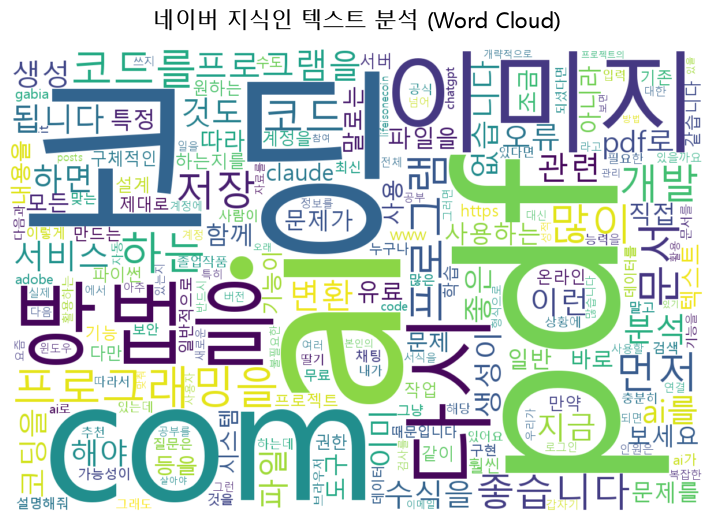

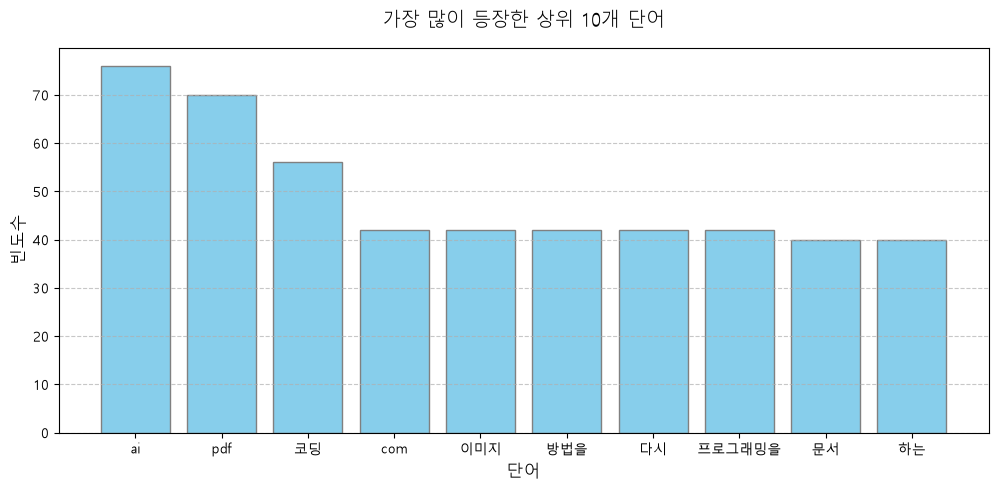

In [6]:
import os
import re
import time
from collections import Counter
from urllib.parse import parse_qs, urlencode, urljoin, urlparse, urlunparse

import shutil
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup
from wordcloud import WordCloud

# ==========================================
# [환경 설정] 윈도우 폰트 시스템 초기화 (단 1회만 실행하여 성능 확보)
# ==========================================
win_cache_path = os.path.expanduser("~/.cache/matplotlib")
if os.path.exists(win_cache_path):
    try:
        shutil.rmtree(win_cache_path)
    except Exception:
        pass

# 2. 윈도우 표준 맑은 고딕 파일(.ttf)의 절대 경로를 Matplotlib 폰트 매니저에 직접 때려 박습니다.
WIN_FONT_PATH = "C:/Windows/Fonts/malgun.ttf"

if os.path.exists(WIN_FONT_PATH):
    # 시스템 리스트를 비우지 않고, 맑은 고딕을 명시적으로 매니저에 수동 등록합니다.
    fm.fontManager.addfont(WIN_FONT_PATH)
    # 등록된 폰트 파일의 고유 Family Name을 가져옵니다. (기본적으로 'Malgun Gothic'이 됩니다.)
    resolved_font_name = fm.FontProperties(fname=WIN_FONT_PATH).get_name()
    plt.rcParams['font.family'] = resolved_font_name
else:
    # 만약의 상황을 대비한 Fallback 시스템 설정
    plt.rcParams['font.family'] = 'sans-serif'

plt.rcParams['axes.unicode_minus'] = False
# ==========================================
# [글로벌 상수 변수 정의]
# ==========================================
START_URL = "https://kin.naver.com/qna/list.naver?dirId=10405&queryTime=2026-07-08%2010%3A22%3A48&page=1"
SAVE_FILE = "naver_kin_qna_with_detail.csv"


# ==========================================
# 크롤링 및 데이터 분석 파이프라인 클래스
# ==========================================
class NaverKinCrawler:
    """네이버 지식인 목록 및 상세 페이지 수집을 담당하는 크롤러 클래스"""

    def __init__(self, start_url, save_file):
        self.start_url = start_url
        self.save_file = save_file
        self.session = requests.Session()
        self.headers = {
            "User-Agent": (
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/124.0.0.0 Safari/537.36"
            ),
            "Referer": "https://kin.naver.com/",
            "Accept-Language": "ko-KR,ko;q=0.9,en-US;q=0.8,en;q=0.7",
        }
        self.session.headers.update(self.headers)
        self.stopwords = set([
            # 1. 제공 데이터셋 내 다수 발견된 지식인 안내/매크로/인사말 노이즈
            "안녕하세요", "질문자님", "네이버", "지식in", "전문", "프로필", "클릭", "홈페이지", 
            "참고", "참고하시기", "상담해", "의도", "개인적인", "사례에", "내용이니", "참고하셨으면",
            "구분", "답변", "질문", "사진", "사진만으로", "진단할", "보이는", "의심되구요",
            "알려주세요", "바랍니다", "추천드립니다", "부탁드립니다", "감사합니다", "도움되셨다면",
            "채택", "부탁드립니다", "추가", "가능합니다", "해 주셨군요", "문의 해주셨군요",
            "답변 구분", "지식파트너", "가비아", "내PC 저장", "MYBOX 저장", "스샷", "첨부파일",
            "이따구로", "난리를", "화가", "제미나이", "클로드", "지피티",

            # 2. LaTeX 및 파일/텍스트 깨짐 관련 노이즈 (데이터셋 내 다수 등장)
            "sqrt", "text", "file-tag", "code-generated-file", "Report", "Week3", "Thursday",
            "LaTeX", "마크다운", "문법", "기호", "특수문자", "수식", "코드블록", "플랫폼",

            # 3. 데이터셋 내 빈도가 높은 범용 동사/형용사 및 상태어
            "합니다", "있습니다", "있으신", "있으며", "있어", "같아요", "등의", "대해", "대해서",
            "경우", "경우가", "때문에", "위해", "위해서", "통해", "의해", "의해서", "통해",
            "해서", "보입니다", "추천드리면요", "만들어주는", "정리해주는", "말씀드리겠습니다",
            "발생하는", "해결하기", "안내해", "드립니다", "안내드리겠습니다", "시도해보세요",

            # 4. 기본 접속사 및 대명사, 범용 부사
            "그리고", "그러나", "그래서", "하지만", "또한", "이것", "저것", "그것", "이게",
            "제가", "저는", "나는", "너무", "정말", "진짜", "혹시", "계속", "현재", "평소",
            "어떤", "어느", "무슨", "어떻게", "왜", "무엇", "어디", "몇", "만", "뿐", "등", "등등", 
            "및", "과", "와", "로", "으로", "고", "하고", "하며", "하면서", "예를", "들어", "들면", "또는",
            "다른", "있는", "같은", "것이", "가장", "도움이"
        ])

    def _clean_text(self, text):
        if not text:
            return ""
        return re.sub(r"\s+", " ", text).strip()

    def _build_page_url(self, page):
        parsed = urlparse(self.start_url)
        query_dict = parse_qs(parsed.query)
        query_dict["page"] = [str(page)]
        new_query = urlencode(query_dict, doseq=True)
        return urlunparse((parsed.scheme, parsed.netloc, parsed.path, parsed.params, new_query, parsed.fragment))

    def _extract_doc_id(self, url):
        parsed = urlparse(url)
        query_dict = parse_qs(parsed.query)
        return query_dict.get("docId", [""])[0]

    def _get_text_by_selectors(self, soup, selectors, find_all=False):
        texts = []
        for selector in selectors:
            if find_all:
                tags = soup.select(selector)
                for tag in tags:
                    text = self._clean_text(tag.get_text(" ", strip=True))
                    if text and text not in texts:
                        texts.append(text)
                if texts:
                    break
            else:
                tag = soup.select_one(selector)
                if tag:
                    text = self._clean_text(tag.get_text(" ", strip=True))
                    if text:
                        return text
        return texts if find_all else ""

    def fetch_detail_text(self, detail_url, delay=0.8):
        """질문 상세 페이지 내 본문과 답변 텍스트를 파싱합니다."""
        try:
            response = self.session.get(detail_url, timeout=10)
            response.raise_for_status()
        except requests.RequestException as e:
            print(f"    [상세 페이지 오류] {detail_url} -> {e}")
            return {"question_text": "", "answers_text": "", "detail_text": ""}

        soup = BeautifulSoup(response.text, "html.parser")

        question_selectors = [
            "div.c-heading__content", "div.c-heading-content", 
            "div.questionDetail", "div.endContentsText", 
            "div.se-main-container", "div._endContentsText"
        ]
        answer_selectors = [
            "div.answer-content__item div.se-main-container", 
            "div.answer-content__item", "div._endContentsText", 
            "div.endContentsText", "div.c-heading-answer__content-user"
        ]

        question_text = self._get_text_by_selectors(soup, question_selectors, find_all=False)
        answer_text_list = self._get_text_by_selectors(soup, answer_selectors, find_all=True)

        answer_text_list = [text for text in answer_text_list if text != question_text]
        answers_text = "\n\n---답변 구분---\n\n".join(answer_text_list)
        detail_text = self._clean_text(question_text + " " + answers_text)

        time.sleep(delay)
        return {
            "question_text": question_text,
            "answers_text": answers_text,
            "detail_text": detail_text,
        }

    def parse_list_page(self, html, page):
        """목록 검색 결과 레이아웃에서 메타데이터 레이어를 가공합니다."""
        soup = BeautifulSoup(html, "html.parser")
        results = []
        seen = set()

        selectors = [
            "td.title a[href*='detail']", ".title a[href*='detail']",
            "dt a[href*='detail']", "a[href*='/qna/detail.naver']", "a[href*='/qna/detail.nhn']"
        ]

        links = []
        for selector in selectors:
            links = soup.select(selector)
            if links:
                break

        for a in links:
            title = self._clean_text(a.get_text(" ", strip=True))
            href = a.get("href", "")

            if not title or not href:
                continue

            full_url = urljoin("https://kin.naver.com", href)
            doc_id = self._extract_doc_id(full_url)

            if not doc_id or doc_id in seen:
                continue

            seen.add(doc_id)

            parent = a.find_parent(["tr", "li", "dl", "div"])
            parent_text = self._clean_text(parent.get_text(" ", strip=True)) if parent else ""

            date_match = re.search(r"\d{4}\.\d{1,2}\.\d{1,2}\.?", parent_text)
            date = date_match.group(0) if date_match else ""

            answer_match = re.search(r"답변\s*(\d+)", parent_text)
            answer_count = answer_match.group(1) if answer_match else ""

            results.append({
                "page": page,
                "doc_id": doc_id,
                "title": title,
                "url": full_url,
                "date": date,
                "answer_count": answer_count,
                "list_raw_text": parent_text,
            })

        return results

    def start_pipeline(self, total_pages=10, list_delay=1.2, detail_delay=0.8):
        """전체 수집 파이프라인의 조율 프로세스를 동작시킵니다."""
        all_data = []

        for page in range(1, total_pages + 1):
            url = self._build_page_url(page)
            print(f"[목록 수집] page={page}/{total_pages} | url={url}")

            try:
                response = self.session.get(url, timeout=10)
                response.raise_for_status()
            except requests.RequestException as e:
                print(f"[오류] 목록 {page}페이지 접근 실패: {e}")
                continue

            list_data = self.parse_list_page(response.text, page)
            print(f" -> {len(list_data)}개의 항목 발견")

            for idx, item in enumerate(list_data, start=1):
                print(f"    [상세 수집] ({idx}/{len(list_data)}): {item['title'][:20]}...")
                detail_data = self.fetch_detail_text(item["url"], delay=detail_delay)
                item.update(detail_data)
                all_data.append(item)

            time.sleep(list_delay)

        return all_data

    def extract_words(self, text):
        text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)
        words = text.split()
        return [w.lower() for w in words if len(w) >= 2 and w not in self.stopwords]

    def visualize_data(self, df):
        if df.empty:
            print("[오류] 분석할 데이터프레임이 비어 있습니다.")
            return

        text_columns = ["title", "question_text", "answers_text", "detail_text"]
        available_columns = [col for col in text_columns if col in df.columns]
        
        df["combined_text"] = df[available_columns].fillna("").agg(" ".join, axis=1)
        all_text = " ".join(df["combined_text"].astype(str))

        words = self.extract_words(all_text)
        word_counts = Counter(words)
        top10_df = pd.DataFrame(word_counts.most_common(10), columns=["word", "count"])

        # 워드클라우드 빌드 (윈도우 로컬 절대 경로 타겟팅)
        wordcloud = WordCloud(
            font_path='C:/Windows/Fonts/malgun.ttf',
            width=1200, height=800,
            background_color="white"
        ).generate_from_frequencies(word_counts)

        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title("네이버 지식인 텍스트 분석 (Word Cloud)", fontsize=16, pad=15)
        plt.show()

        # 상위 분포 막대그래프 빌드
        plt.figure(figsize=(12, 5))
        plt.bar(top10_df["word"], top10_df["count"], color="skyblue", edgecolor="gray")
        plt.title("가장 많이 등장한 상위 10개 단어", fontsize=14, pad=15)
        plt.xlabel("단어", fontsize=12)
        plt.ylabel("빈도수", fontsize=12)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()


# ==========================================
# 프로그램 런타임 엔트리포인트 (Main)
# ==========================================
if __name__ == "__main__":
    # 크롤러 모듈 인스턴스화 및 실행
    crawler = NaverKinCrawler(start_url=START_URL, save_file=SAVE_FILE)
    raw_data = crawler.start_pipeline(total_pages=10, list_delay=1.2, detail_delay=0.8)
    
    data_df = pd.DataFrame(raw_data)

    if not data_df.empty:
        # 데이터 무결성 체크 및 중복 제거 후 로컬 저장
        data_df = data_df.drop_duplicates(subset=["doc_id"])
        data_df.to_csv(SAVE_FILE, index=False, encoding="utf-8-sig")

        print("\n" + "=" * 40)
        print(f"[성공] 데이터 인프라 수집 및 아카이빙 완료.")
        print(f" - 적재된 유니크 데이터 건수: {len(data_df)} 건")
        print(f" - CSV 저장 경로: {os.path.abspath(SAVE_FILE)}")
        print("=" * 40 + "\n")

        # 시각화 데이터 렌더링 호출
        crawler.visualize_data(data_df)
    else:
        print("[실패] 파이프라인에서 수집된 적재 셋이 존재하지 않습니다. 구조 변경 또는 웹 사이트 차단 여부를 확인하세요.")